C:\Users\alexo\AppData\Local\Temp\ipykernel_36736\1421990212.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True, header=None)
C:\Users\alexo\AppData\Local\Temp\ipykernel_36736\1421990212.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True, header=None)


SVM (Gradient Descent) - Training Accuracy: 99.68%
SVM (Gradient Descent) - Testing Accuracy: 97.88%
SVM (Coordinate Descent) - Training Accuracy: 99.62%
SVM (Coordinate Descent) - Testing Accuracy: 97.88%


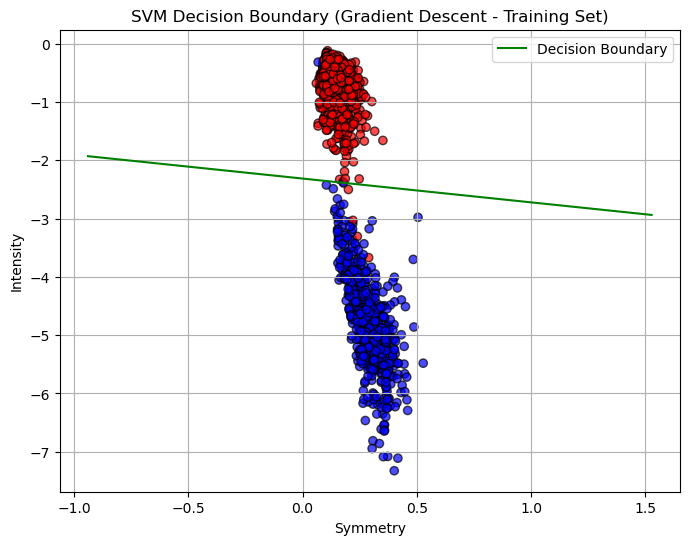

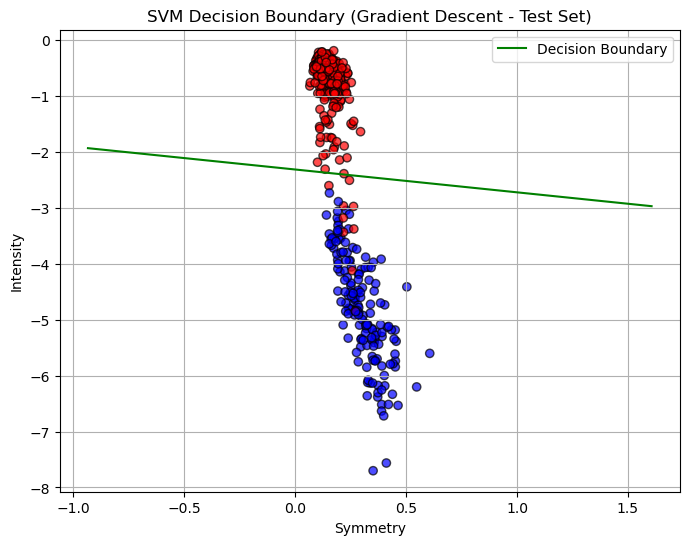

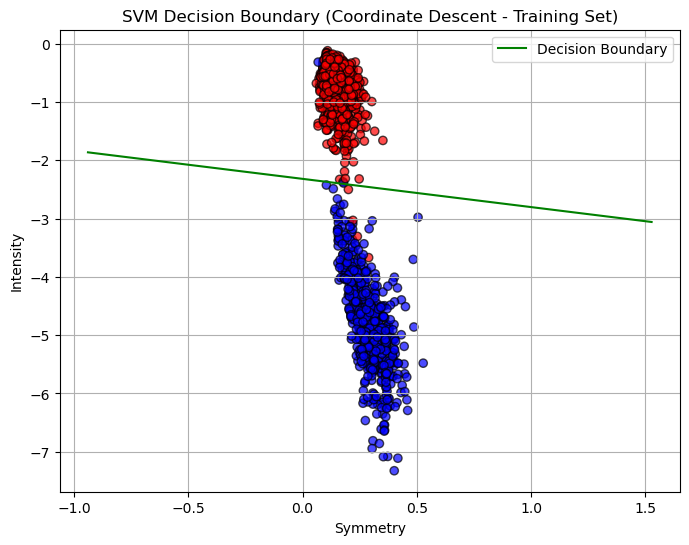

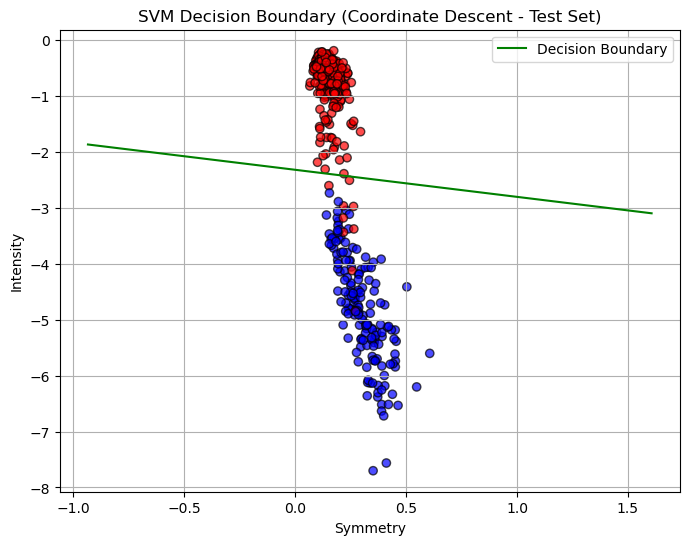

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Load and filter data function
def load_and_filter_data(file_path):
    data = pd.read_csv(file_path, delim_whitespace=True, header=None)
    data = data[(data.iloc[:, 0] == 1) | (data.iloc[:, 0] == 5)]
    data.iloc[:, 0] = data.iloc[:, 0].map({1: 1, 5: -1})  # Map labels to +1 and -1 for SVM
    labels = data.iloc[:, 0].values
    features = data.iloc[:, 1:].values
    return features, labels

# Load training and testing data
X_train, y_train = load_and_filter_data('features_train.txt')
X_test, y_test = load_and_filter_data('features_test.txt')

# Add bias term to features
X_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

# Corrected SVM with Gradient Descent
def svm_gradient_descent(X, y, lr=0.01, iterations=1000, C=1):
    m, n = X.shape
    w = np.zeros(n)
    for _ in range(iterations):
        margin = y * (X @ w) 
        indicator = (margin < 1).astype(float).reshape(-1, 1) 
        gradient = w - C * np.sum(indicator * y.reshape(-1, 1) * X, axis=0) 
        w -= lr * gradient
    return w

# SVM with Coordinate Descent
def svm_coordinate_descent(X, y, iterations=1000, C=1):
    m, n = X.shape
    w = np.zeros(n)
    for _ in range(iterations):
        for j in range(n):  # Update one coordinate at a time
            margin = y * (X @ w)
            gradient_j = w[j] - C * np.sum((margin < 1) * y * X[:, j])
            w[j] -= 0.01 * gradient_j
    return w

# Train models
w_svm_gd = svm_gradient_descent(X_train, y_train, lr=0.01, iterations=1000, C=1)
w_svm_cd = svm_coordinate_descent(X_train, y_train, iterations=1000, C=1)

# Calculate accuracies
def calculate_accuracy(X, y, w):
    y_pred = np.sign(X @ w)
    return accuracy_score(y, y_pred)

accuracy_train_gd = calculate_accuracy(X_train, y_train, w_svm_gd)
accuracy_test_gd = calculate_accuracy(X_test, y_test, w_svm_gd)
accuracy_train_cd = calculate_accuracy(X_train, y_train, w_svm_cd)
accuracy_test_cd = calculate_accuracy(X_test, y_test, w_svm_cd)

print(f"SVM (Gradient Descent) - Training Accuracy: {accuracy_train_gd * 100:.2f}%")
print(f"SVM (Gradient Descent) - Testing Accuracy: {accuracy_test_gd * 100:.2f}%")
print(f"SVM (Coordinate Descent) - Training Accuracy: {accuracy_train_cd * 100:.2f}%")
print(f"SVM (Coordinate Descent) - Testing Accuracy: {accuracy_test_cd * 100:.2f}%")

# Plot decision boundaries
def plot_decision_boundary(X, y, w, title):
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 1], X[:, 2], c=y, cmap='bwr', alpha=0.7, edgecolors='k')
    x_min, x_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    x_values = np.linspace(x_min, x_max, 100)
    y_values = -(w[0] + w[1] * x_values) / w[2]
    plt.plot(x_values, y_values, color='green', label='Decision Boundary')
    plt.title(title)
    plt.xlabel('Symmetry')  # Updated label
    plt.ylabel('Intensity')  # Updated label
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot for Gradient Descent
plot_decision_boundary(X_train, y_train, w_svm_gd, 'SVM Decision Boundary (Gradient Descent - Training Set)')
plot_decision_boundary(X_test, y_test, w_svm_gd, 'SVM Decision Boundary (Gradient Descent - Test Set)')

# Plot for Coordinate Descent
plot_decision_boundary(X_train, y_train, w_svm_cd, 'SVM Decision Boundary (Coordinate Descent - Training Set)')
plot_decision_boundary(X_test, y_test, w_svm_cd, 'SVM Decision Boundary (Coordinate Descent - Test Set)')
